In [ ]:
# try install everything in torchcfm env

In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd

/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
larry = sc.read_h5ad("data/Weinreb2020_fate_prediction.h5ad")
adata = sc.read_h5ad("data/klein_subset.h5ad")
Fate_bias = pd.read_csv("data/Weinreb/F_obs.csv", index_col=0)
Fate_bias.index = Fate_bias.index.astype(str)

overlapped_cbs = np.intersect1d(Fate_bias.index, adata.obs_names)

In [51]:
adata.obs.query("`Well` in [0,1]").Time_point.value_counts()

Time_point
6.0    12462
4.0     6092
2.0     4505
Name: count, dtype: int64

/ssd/users/Wergillius/miniforge3/envs/torchcfm/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


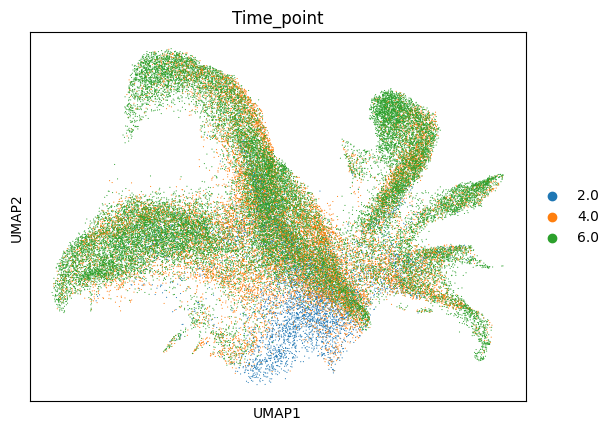

In [58]:
sc.pl.umap(adata, color='Time_point')

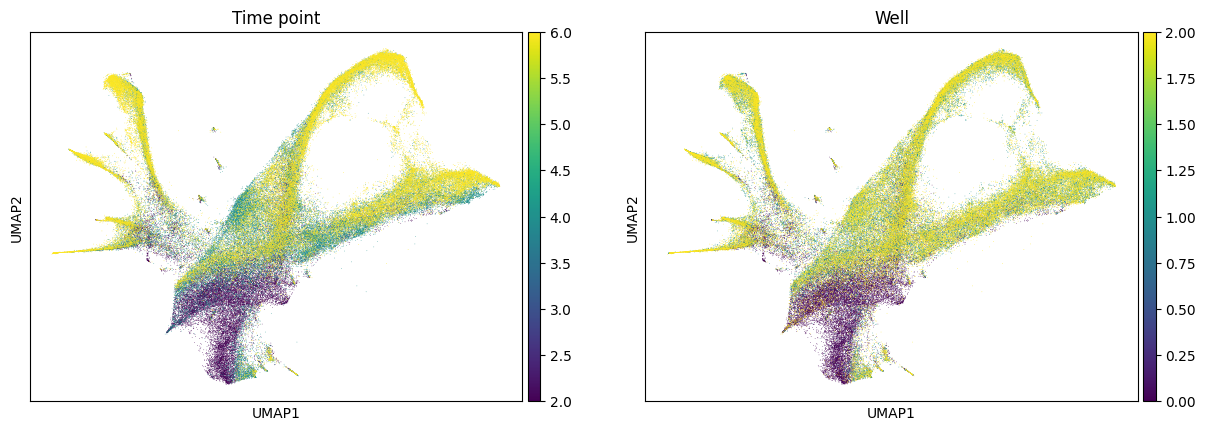

In [60]:
sc.pl.umap(larry, color=['Time point', 'Well'])

In [55]:
larry.obs.query("`Well` in [0,1]")['Time point'].value_counts()

Time point
2.0    28249
6.0    24511
4.0    21300
Name: count, dtype: int64

In [42]:
adata.obs.Time_point.value_counts()

Time_point
6.0    28727
4.0    14675
2.0     4505
Name: count, dtype: int64

In [40]:
adata.obs.loc[overlapped_cbs].Time_point.unique()

['2.0']
Categories (3, object): ['2.0', '4.0', '6.0']

In [ ]:
print('fate bias cells for testing', Fate_bias.shape[0])
print('the number of overlapped cells', len(overlapped_cbs))

fate bias cells for testing 2081
the number of overlapped cells 1989


In [7]:
adata.obs.head()

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group,timepoint_tx_days,selected_clonal_cells,Day2_u,Day4_u,Day6_u,palantir_pseudotime,palantir_entropy
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573,8,8,6.0,True,6.313256e-05,0.000072,0.000068,0.059343,1.158957e+00
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,8,6.0,True,4.673292e-07,0.000003,0.000006,0.355230,3.426110e-01
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394,0,0,6.0,True,2.084716e-06,0.000009,0.000015,0.105826,6.385202e-01
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,4,6.0,True,2.516037e-06,0.000007,0.000011,0.188384,7.857315e-01
6,6.0,LK,Neutrophil,2,6.0,7,Neutrophil_7,prog_Neu,Clone_1450,3,3,6.0,True,1.135646e-07,0.000005,0.000007,0.412705,6.750768e-97


In [13]:
larry.obs

,Library,Cell barcode,Time point,Starting population,Cell type annotation,Well,SPRING-x,SPRING-y,clone_idx,fate_observed,t0_fated,train,test
0,d6_2_2,GCGTGCAA-AGAAGTTA,6.0,Lin-Kit+Sca1-,Undifferentiated,2,411.496,-96.190,573.0,False,False,False,True
1,d6_2_2,AAGGGACC-CTCGATGC,6.0,Lin-Kit+Sca1-,Undifferentiated,2,-587.462,-306.925,1440.0,False,False,False,True
2,d6_2_2,CGTACCGA-AGCGCCTT,6.0,Lin-Kit+Sca1-,Monocyte,2,1429.805,-429.300,394.0,False,False,False,True
3,d6_2_2,CTGAAGGG-AGGAGCTT,6.0,Lin-Kit+Sca1-,Neutrophil,2,1150.028,-2030.369,NaN,False,False,False,True
4,d6_2_2,CCGTAGCT-AGGCAGTT,6.0,Lin-Kit+Sca1-,Undifferentiated,2,-1169.594,362.010,1972.0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130882,LSK_d6_1_3,TCTGATTT-CGGGCTTT,6.0,Lin-Kit+Sca1+,Undifferentiated,1,-308.468,-163.223,NaN,False,False,True,False
130883,LSK_d6_1_3,AGTCACAA-TGTGTCCT,6.0,Lin-Kit+Sca1+,Undifferentiated,1,-3.435,575.133,1374.0,False,False,True,False
130884,LSK_d6_1_3,GGAGGTTT-AGGCAGTT,6.0,Lin-Kit+Sca1+,Monocyte,1,2548.309,24.683,NaN,False,False,True,False
130885,LSK_d6_1_3,CCGGAAAT-GGGAAGGT,6.0,Lin-Kit+Sca1+,Monocyte,1,2658.601,131.098,NaN,False,False,True,False


In [18]:
larry.obs.query("`train` == True").shape

(74060, 13)

In [19]:
larry.obs.query("`test` == True").shape

(85076, 13)

In [17]:
test_obs = larry.obs.query("`test` == True")
test_cb = test_obs.index
test_obs.Well.value_counts()

Well
2    56827
0    28249
Name: count, dtype: int64